# Project 43 — Explainable Disaster Severity Assessment
## Notebook 04: Dashboard Dev & Integration Tests
**C-DAC Mohali | ML to Generative AI & LLMs**
Team: Anuksha | Rishika | Ipshita

This notebook exercises `utils/predict.py`, `utils/gradcam.py`,
`utils/zonemap.py`, and `utils/report.py` **exactly as `app/app.py` calls
them** — a local, Windows-friendly smoke test to run before demoing the
Streamlit dashboard. It is a dev/testing notebook, not a training notebook.

Like notebooks 01–03, it locates the project root by walking up from the
current working directory until it finds a folder containing `data/` — no
hardcoded absolute paths, and no Google Colab / Drive dependencies.

## 1. Setup
Find the project root, put it on `sys.path`, import the shared utilities, and
load `models/best_model.h5`. If the model is missing, every section below
prints a clear "skipped" message instead of crashing.

In [1]:
import os, sys, glob, warnings, logging
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # hide TF C++ info/warns
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Keep output clean for readers (inference-only, CPU is expected here).
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)
try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
except Exception:
    pass


def find_project_root(marker="data", max_up=5):
    """Walk up from cwd until a directory containing `marker/` is found."""
    cur = Path.cwd().resolve()
    for _ in range(max_up + 1):
        if (cur / marker).is_dir():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not locate project root containing '{marker}/' "
        f"starting from {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root("data")
print("Project root:", PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.predict import (
    load_model, preprocess_image, predict, CLASS_NAMES, LOW_CONFIDENCE_THRESHOLD,
)
from utils.gradcam import (
    get_gradcam_heatmap, get_gradcam_plus_plus_heatmap,
    overlay_heatmap, compute_average_drop, predict_and_explain,
)
from utils.zonemap import zone_damage_map, CLASS_COLORS
from utils.report import build_report_pdf

TEST_DIR = PROJECT_ROOT / "data" / "Test"
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)
MODEL_PATH = PROJECT_ROOT / "models" / "best_model.h5"

print("CLASS_NAMES:", CLASS_NAMES)
print("Low-confidence threshold:", LOW_CONFIDENCE_THRESHOLD)

Project root: C:\Users\Ipshita\OneDrive\Desktop\Project43-DisasterSeverity
CLASS_NAMES: ('Earthquake', 'Fire', 'Flood', 'Normal')
Low-confidence threshold: 0.6


In [2]:
MODEL = None
if MODEL_PATH.is_file():
    MODEL = load_model(str(MODEL_PATH))
    IMG_SIZE = MODEL.input_shape[1:3]
    print(f"Loaded {MODEL_PATH.name}  |  input size {IMG_SIZE}  |  "
          f"{MODEL.count_params():,} params")
else:
    IMG_SIZE = (224, 224)
    print("=" * 70)
    print("models/best_model.h5 NOT found.")
    print("Run notebooks/02_model_training.ipynb to train and promote the model.")
    print("The test sections below will be skipped until the model exists.")
    print("=" * 70)

Loaded best_model.h5  |  input size (224, 224)  |  4,378,535 params


In [3]:
def sample_image_per_class(n=1):
    """{class_name: [first n test image paths]} — handles png/jpg/jpeg."""
    out = {}
    for cls in CLASS_NAMES:
        files = sorted(
            glob.glob(str(TEST_DIR / cls / "*.png"))
            + glob.glob(str(TEST_DIR / cls / "*.jpg"))
            + glob.glob(str(TEST_DIR / cls / "*.jpeg"))
        )
        out[cls] = files[:n]
    return out


samples = {c: v[0] for c, v in sample_image_per_class(1).items() if v}
print("One test image per class:")
for c, p in samples.items():
    print(f"  {c:12s} -> {os.path.basename(p)}")

One test image per class:
  Earthquake   -> image_0.png
  Fire         -> image_1218.png
  Flood        -> image_239.png
  Normal       -> image_1000.png


## 2. Test `predict.py` end-to-end
One real image per class through `preprocess_image()` + `predict()`. We print
the true class, predicted class, and the full confidence dict, and check
whether the low-confidence `warning` key is present. Real test images are
high-confidence, so the flag stays off here — Section 4 triggers it on
purpose.

In [4]:
if MODEL is not None:
    rows = []
    for true_cls, img_path in samples.items():
        arr = preprocess_image(img_path, target_size=IMG_SIZE)
        pred_cls, conf = predict(MODEL, arr)
        top = conf[pred_cls]
        warned = "warning" in conf
        print(f"True: {true_cls:12s} | Pred: {pred_cls:12s} | "
              f"Conf: {top:6.2%} | warning_key: {warned}")
        print("   probs:", {k: round(float(v), 4) for k, v in conf.items() if k != "warning"})
        if warned:
            print("   ->", conf["warning"])
        rows.append({"true": true_cls, "pred": pred_cls, "confidence": top,
                     "correct": true_cls == pred_cls, "warning": warned})

    df_pred = pd.DataFrame(rows)
    print()
    print(df_pred.to_string(index=False))
    print(f"\nAccuracy on these {len(rows)} samples: {df_pred['correct'].mean():.0%}")
else:
    print("Skipped - model not available.")

True: Earthquake   | Pred: Earthquake   | Conf: 99.93% | warning_key: False
   probs: {'Earthquake': 0.9993, 'Fire': 0.0, 'Flood': 0.0007, 'Normal': 0.0}
True: Fire         | Pred: Fire         | Conf: 100.00% | warning_key: False
   probs: {'Earthquake': 0.0, 'Fire': 1.0, 'Flood': 0.0, 'Normal': 0.0}
True: Flood        | Pred: Flood        | Conf: 100.00% | warning_key: False
   probs: {'Earthquake': 0.0, 'Fire': 0.0, 'Flood': 1.0, 'Normal': 0.0}
True: Normal       | Pred: Normal       | Conf: 100.00% | warning_key: False
   probs: {'Earthquake': 0.0, 'Fire': 0.0, 'Flood': 0.0, 'Normal': 1.0}

      true       pred  confidence  correct  warning
Earthquake Earthquake    0.999339     True    False
      Fire       Fire    1.000000     True    False
     Flood      Flood    0.999961     True    False
    Normal     Normal    0.999970     True    False

Accuracy on these 4 samples: 100%


## 3. Test `gradcam.py` end-to-end
For each class image: generate a Grad-CAM and a Grad-CAM++ heatmap, blend them
with `overlay_heatmap()`, and show an **Original | Grad-CAM | Grad-CAM++**
triptych inline (one row per class). The first row is also saved to
`outputs/gradcam_test_sample.png`.

Note: `preprocess_image()` applies EfficientNet's `preprocess_input`, which is
a pass-through leaving pixels in **[0, 255]** — so for display we clip to that
range rather than rescaling by 255.

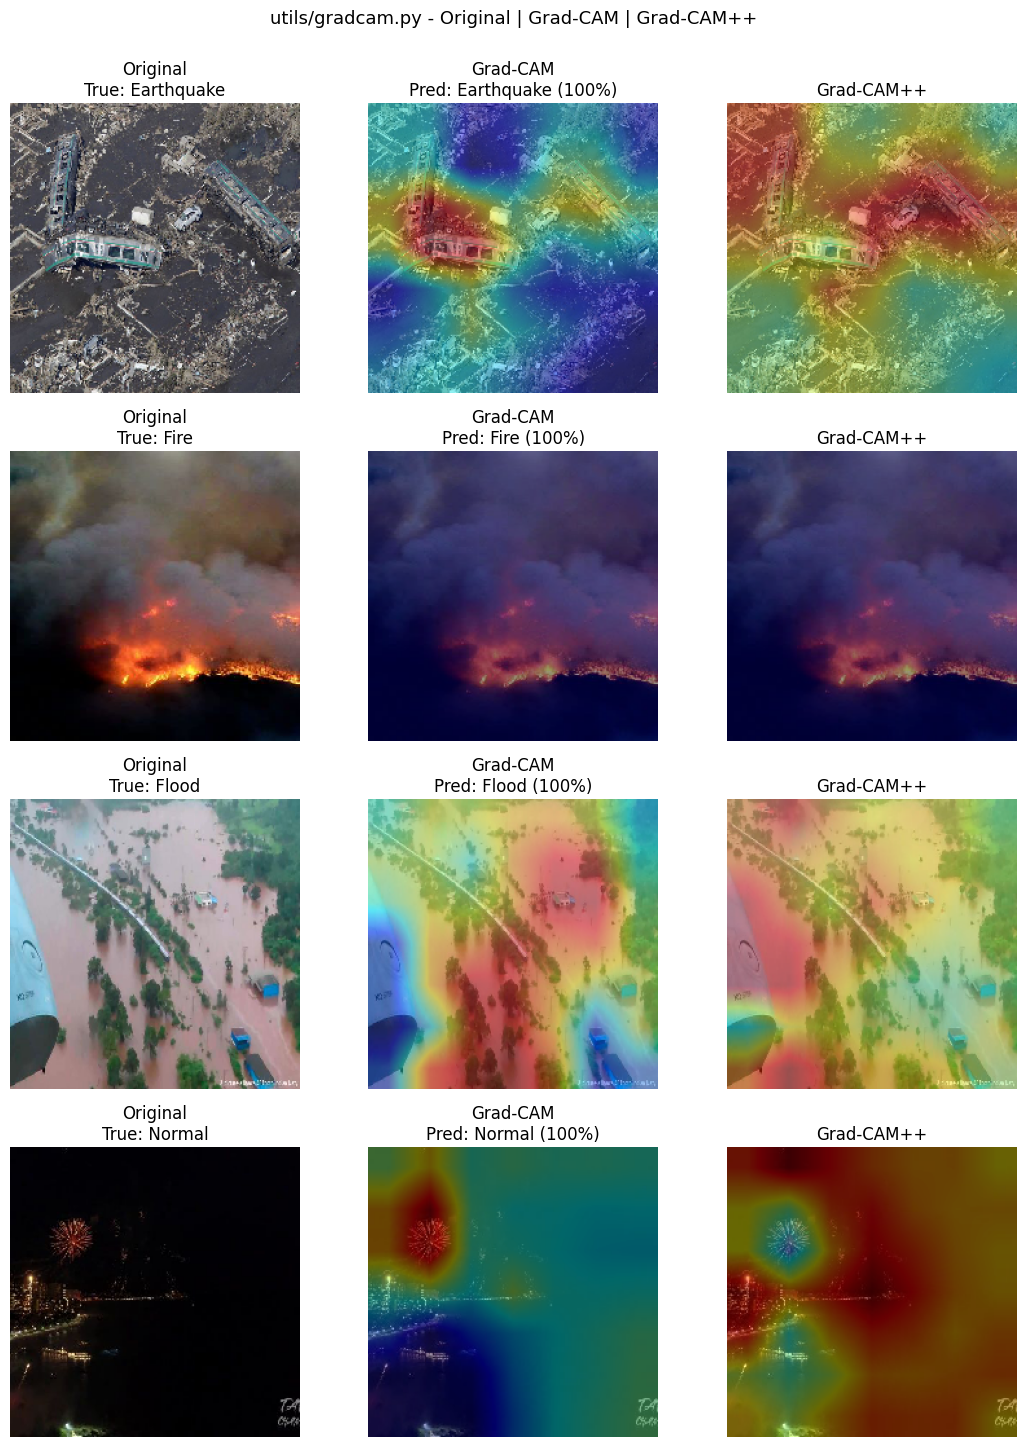

Saved: outputs/gradcam_test_sample.png


In [5]:
if MODEL is not None:
    n = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(11, 3.6 * n))
    if n == 1:
        axes = axes[None, :]

    saved = False
    for row, (true_cls, img_path) in enumerate(samples.items()):
        arr = preprocess_image(img_path, target_size=IMG_SIZE)
        pred_cls, conf = predict(MODEL, arr)
        cls_idx = CLASS_NAMES.index(pred_cls)

        disp = np.uint8(np.clip(arr[0], 0, 255))  # EfficientNet inputs are [0,255]
        hm = get_gradcam_heatmap(MODEL, arr, cls_idx)
        hmpp = get_gradcam_plus_plus_heatmap(MODEL, arr, cls_idx)
        _, ov = overlay_heatmap(hm, disp)
        _, ovpp = overlay_heatmap(hmpp, disp)

        axes[row, 0].imshow(disp)
        axes[row, 0].set_title(f"Original\nTrue: {true_cls}"); axes[row, 0].axis("off")
        axes[row, 1].imshow(ov)
        axes[row, 1].set_title(f"Grad-CAM\nPred: {pred_cls} ({conf[pred_cls]:.0%})"); axes[row, 1].axis("off")
        axes[row, 2].imshow(ovpp)
        axes[row, 2].set_title("Grad-CAM++"); axes[row, 2].axis("off")

        if not saved:
            sfig, sax = plt.subplots(1, 3, figsize=(11, 3.6))
            for a, im, t in zip(sax, [disp, ov, ovpp], ["Original", "Grad-CAM", "Grad-CAM++"]):
                a.imshow(im); a.set_title(t); a.axis("off")
            sfig.suptitle(f"Grad-CAM test sample - {true_cls}")
            sfig.tight_layout()
            sfig.savefig(OUT_DIR / "gradcam_test_sample.png", dpi=140, bbox_inches="tight")
            plt.close(sfig)
            saved = True

    plt.suptitle("utils/gradcam.py - Original | Grad-CAM | Grad-CAM++", y=1.002, fontsize=13)
    plt.tight_layout()
    plt.show()
    print("Saved: outputs/gradcam_test_sample.png")
else:
    print("Skipped - model not available.")

## 4. Test confidence thresholding
Batch-scan several real images per class and bucket them into **high (>80%)**,
**medium (60–80%)**, and **low (<60%)** confidence. Then verify the
`warning`-flag mechanism: `predict()` inserts a `warning` key when the top
probability drops below `LOW_CONFIDENCE_THRESHOLD` (0.60). We demonstrate this
on a genuine low-confidence test image found in the scan, falling back to an
ambiguous "mean of all four classes" probe if the scan happens to contain
none.

In [6]:
if MODEL is not None:
    scan = sample_image_per_class(n=12)
    paths, trues = [], []
    for cls, files in scan.items():
        for p in files:
            paths.append(p); trues.append(cls)

    batch = np.vstack([preprocess_image(p, target_size=IMG_SIZE) for p in paths])
    probs = MODEL.predict(batch, verbose=0)
    tops = probs.max(axis=1)

    def bucket(c):
        if c > 0.80:
            return "high (>80%)"
        if c >= 0.60:
            return "medium (60-80%)"
        return "low (<60%)"

    dfc = pd.DataFrame({
        "path": paths,
        "image": [os.path.basename(p) for p in paths],
        "true": trues,
        "pred": [CLASS_NAMES[i] for i in probs.argmax(axis=1)],
        "confidence": tops,
        "bucket": [bucket(c) for c in tops],
    })
    print(f"Confidence buckets across {len(dfc)} real test images:")
    print(dfc["bucket"].value_counts().to_string())
    print()
    for b in ["high (>80%)", "medium (60-80%)", "low (<60%)"]:
        sub = dfc[dfc.bucket == b]
        if len(sub):
            r = sub.iloc[0]
            print(f"  {b:16s} e.g. {r['image']} ({r['true']}) -> {r['pred']} {r['confidence']:.1%}")
        else:
            print(f"  {b:16s} none among these real images")

    # --- Verify the warning flag actually fires below the threshold ---
    # Prefer a genuine low-confidence test image; if this scan happens to have
    # none, fall back to an ambiguous "mean of all 4 classes" probe.
    print("\n--- Warning-flag mechanism ---")
    low = dfc[dfc.confidence < LOW_CONFIDENCE_THRESHOLD].sort_values("confidence")
    if len(low):
        probe = preprocess_image(low.iloc[0]["path"], target_size=IMG_SIZE)
        probe_label = f"real low-conf image ({low.iloc[0]['image']})"
    else:
        arrs = [preprocess_image(p, target_size=IMG_SIZE) for p in samples.values()]
        probe = np.mean(arrs, axis=0).astype(np.float32)
        probe_label = "mean of all 4 classes (ambiguous)"

    confident = preprocess_image(samples[CLASS_NAMES[1]], target_size=IMG_SIZE)
    for label, arr in [("confident image", confident), (probe_label, probe)]:
        pred_cls, conf = predict(MODEL, arr)
        print(f"  {label:42s} pred={pred_cls:12s} conf={conf[pred_cls]:6.1%} "
              f"warning_key={'warning' in conf}")
        if "warning" in conf:
            print("      ->", conf["warning"])

    print(f"\nConfirmed: predict() adds a 'warning' key iff top prob < "
          f"{LOW_CONFIDENCE_THRESHOLD:.0%}.")
else:
    print("Skipped - model not available.")

Confidence buckets across 48 real test images:
bucket
high (>80%)    47
low (<60%)      1

  high (>80%)      e.g. image_0.png (Earthquake) -> Earthquake 99.9%
  medium (60-80%)  none among these real images
  low (<60%)       e.g. image_1005.png (Normal) -> Normal 53.5%

--- Warning-flag mechanism ---
  confident image                            pred=Fire         conf=100.0% warning_key=False
  real low-conf image (image_1005.png)       pred=Normal       conf= 53.5% warning_key=True
      -> Low confidence (53.5%) — top class 'Normal' is below the 60% threshold; consider manual review.

Confirmed: predict() adds a 'warning' key iff top prob < 60%.


## 5. Test `zonemap.py` (zone damage map)
Run the tile-based zone analysis on one test image and show the color-coded
overlay inline. A single 224×224 test image resolves to one tile; upload a
larger aerial image in the app's **Zone Analysis** tab to see a real grid.

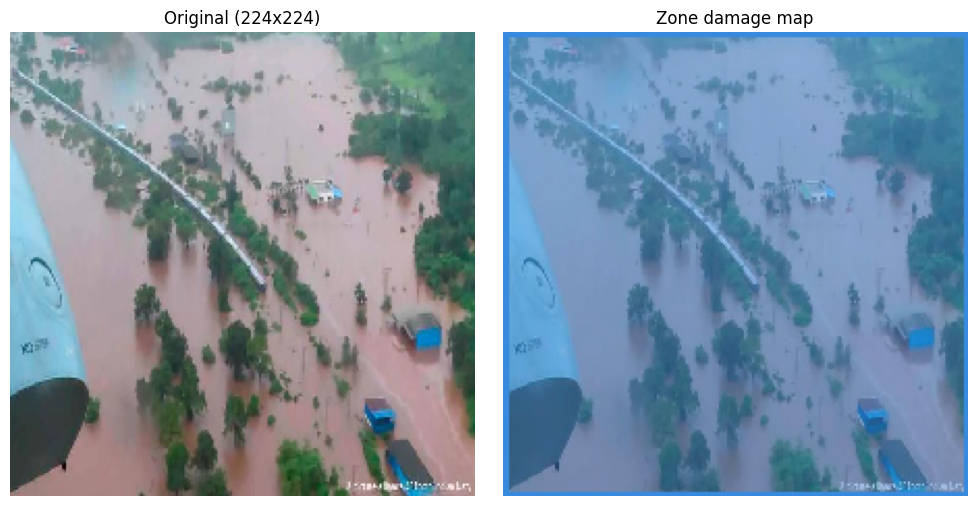

Grid: (1, 1)  |  tiles: 1  |  damage: 100%  (1/1)
Per-class zone counts: {'Earthquake': 0, 'Fire': 0, 'Flood': 1, 'Normal': 0}


In [7]:
if MODEL is not None:
    zone_path = samples[CLASS_NAMES[2]]  # a Flood image
    pil = Image.open(zone_path).convert("RGB")
    overlay, stats = zone_damage_map(MODEL, pil)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(pil)
    ax[0].set_title(f"Original ({pil.size[0]}x{pil.size[1]})"); ax[0].axis("off")
    ax[1].imshow(overlay)
    ax[1].set_title("Zone damage map"); ax[1].axis("off")
    plt.tight_layout(); plt.show()

    print(f"Grid: {stats['grid_shape']}  |  tiles: {stats['n_tiles']}  |  "
          f"damage: {stats['damage_pct']:.0f}%  ({stats['n_damage']}/{stats['n_tiles']})")
    print("Per-class zone counts:", stats["class_counts"])
else:
    print("Skipped - model not available.")

## 6. Test `report.py` (PDF export)
Generate a one-page PDF report for a single image via `build_report_pdf()`
(the same call the app's **Download PDF Report** button makes) and save it to
`outputs/test_report.pdf`.

In [8]:
if MODEL is not None:
    res = predict_and_explain(MODEL, samples[CLASS_NAMES[1]])  # a Fire image
    pdf_bytes = build_report_pdf(
        original_img=res["original"],
        gradcam_img=res["overlay"],
        pred_class=res["class"],
        confidence=res["confidence"],
        all_probs=res["all_probs"],
        average_drop=res["average_drop"],
    )
    pdf_path = OUT_DIR / "test_report.pdf"
    pdf_path.write_bytes(pdf_bytes)
    print(f"Saved: outputs/test_report.pdf  ({len(pdf_bytes):,} bytes)")
    print("Valid PDF header:", pdf_bytes[:5] == b"%PDF-")
    print(f"Report is for: {res['class']} ({res['confidence']:.1%}), "
          f"Grad-CAM avg drop {res['average_drop']:.1f}%")
else:
    print("Skipped - model not available.")

Saved: outputs/test_report.pdf  (158,961 bytes)
Valid PDF header: True
Report is for: Fire (100.0%), Grad-CAM avg drop 0.0%


## 7. Streamlit app — manual testing checklist
Sections 2–6 verify the utility layer that `app/app.py` sits on top of. Before
the demo, launch the app and walk through this checklist by hand:

```bash
python -m streamlit run app/app.py
```

- [ ] **Sample buttons** load and classify correctly for all 4 classes
      (Earthquake, Fire, Flood, Normal).
- [ ] **Grad-CAM overlays** display correctly in the 3-column
      Original | Grad-CAM | Grad-CAM++ view.
- [ ] **PDF download** ("Download PDF Report") produces a valid, readable PDF.
- [ ] **Zone Analysis** runs and shows the color-coded damage map + summary
      (test both a normal image and a large >448px aerial image).
- [ ] **Model Performance** tab shows training curves and the confusion matrix,
      plus the classification-report and model-comparison tables.
- [ ] **Confidence threshold slider** raises the "human review recommended"
      warning when set above a prediction's confidence.
- [ ] **Graceful failure**: temporarily rename `models/best_model.h5` and
      confirm the app shows a clear error instead of a stack trace, then
      rename it back.

If every box above is checked and this notebook ran top-to-bottom without
errors, the project is demo-ready.